# Agentic forecasting step-by-step

**skforecast-ai** is an **AI forecasting assistant** that pairs a deterministic engine, powered by [**skforecast**](https://skforecast.org), with an **LLM reasoning layer**. Simply provide a time series, and the assistant automatically profiles the data, selects a model using established best practices, and evaluates its performance. It returns both the final forecast and the runnable skforecast script that produced it.

This tutorial walks through the **step-by-step path**: the approach for users who want granular control to inspect or adjust intermediate decisions before committing to a full run. If you prefer a single-call workflow that returns results immediately, see the [fast-path tutorial](./agentic-forecasting.html).

Both paths share the same deterministic engine and produce identical results and reproducible `skforecast` code. The step-by-step path gives you three additional capabilities:

+ **Inspect intermediate objects**: examine the `ForecastingProfile` and `ForecastPlan` before any model is trained, and confirm the assistant's recommendations make sense for your domain.

+ **Override any single decision**: change the estimator, lags, window features, or preprocessing without re-running the entire pipeline from scratch. Pass the modified plan directly to `forecast()` or `backtest()`.

+ **Reuse the profile and plan across branches**: build the profile and plan once, then run `forecast()` for future predictions, `backtest()` for historical evaluation, and `compare()` to rank several candidate configurations: each reusing the same profile, with no redundant profiling.

The `ask()` method is available at every stage. It interprets what you pass to it (a profile, a plan, a forecast result, a backtest result, or a comparison result), but it never executes the workflow or silently changes any recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path: one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path: full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

</div>

  <!-- compare() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #bc4c00; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#bc4c00; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">Model selection: which forecaster should you use?</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#fff4ed; font-size:13px;">
      <p style="margin:0 0 12px 0;"><code>compare()</code> answers the question every forecasting project starts with: <b>Among several reasonable models, which one actually performs best on my data?</b> Every candidate is evaluated using the same data and cross-validation strategy. Therefore, the differences you see come from the models, not from the setup.</p>
      <table style="width:100%; border:0; border-collapse:collapse; table-layout:fixed; background:transparent; box-shadow:none; margin:0;">
        <tbody style="border:0; background:transparent;">
        <tr style="border:0; background:transparent;">
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">Candidates</span><br><span style="font-size:12px; color:#57606a;">A handful of configurations worth testing: different forecasters, estimators, lags or window features. Supply your own, or let the data profile propose them.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:34%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffe0cc; border:1px solid #bc4c00; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:700;">compare()</span><br><span style="font-size:12px; color:#57606a;">Runs a full backtest for each candidate under identical conditions, and scores them with the metrics you care about.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">A ranked answer</span><br><span style="font-size:12px; color:#57606a;">A leaderboard sorted best to worst, the reproducible code behind every row, and the winner ready to be used for forecasting or further tuning.</span></div>
          </td>
        </tr>
        </tbody>
      </table>
      <p style="margin:12px 0 0 0; font-size:12px; color:#57606a; text-align:center;">The ranking is a plain sort of the metric column: fully deterministic and auditable. The LLM plays no part in choosing the winner.</p>
    </div>
  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">LLM reasoning: available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code>, a <code>plan</code>, a <code>result</code> (from <code>forecast()</code>, <code>backtest()</code> or <code>compare()</code>), or nothing at all (pure Q&amp;A).</div>
  </div>
</div>

The following example walks through the **step-by-step** allowing user to understand and control what happens under the hood. If you prefer the quickest way to go from raw data to a validated forecast with minimal setup, visit the [fast-path tutorial](./agentic-forecasting.html).

## Assistant initialization

The first step is to instantiate a `ForecastingAssistant`, which will be responsible for executing the entire workflow (profiling, planning, backtesting, and forecasting), as well as explaining the outputs and suggesting improvements.

To activate the optional LLM support, users must pass a string in the format `'provider:model_name'` (for example, `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`). For hosted providers, the corresponding API key must be available as an environment variable or passed explicitly when creating the assistant. In this tutorial, we set `send_data_to_llm=False`. This ensures strict data privacy: the LLM receives only metadata and summary statistics, never the raw time series values.

In [42]:
# Data processing
# ==============================================================================
import os
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold
from skforecast.plot import set_dark_theme

# Python utilities
# ==============================================================================
import textwrap

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.3.0
Version skforecast: 0.24.0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    If you do not have access to an LLM, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured LLM; their deterministic counterparts work without one.
  </p>

</div>

In [43]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-3.5-flash"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Using AWS Bedrock
# ==============================================================================
# assistant = ForecastingAssistant(
#     llm='bedrock:eu.anthropic.claude-sonnet-4-6',
#     base_url="eu-west-1"
# )

# Assistant without LLM (deterministic only)
# ==============================================================================
# assistant = ForecastingAssistant()

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Your data stays private</strong>
</p>

<p>
By default, enabling an LLM does not send your time-series data to the model provider.
The assistant passes only summary statistics, detected frequency,
seasonality flags and the forecaster configuration, never the raw observations.
To explicitly allow it, pass <code>send_data_to_llm=True</code>.
</p>

</div>

## Data

The data used in this tutorial represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available.

In [44]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data['date_time'] = pd.to_datetime(data['date_time'])
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>

</div>

In [45]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Users')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Profile the data

The `profile()` method is the first stage of the step-by-step workflow. It inspects the dataset and returns a `ForecastingProfile` object that contains:

+ **Data metadata**: detected frequency, index type, series lengths, missing values, and exogenous column roles.

+ **Modeling recommendations**: the selected forecaster family and estimator, along with alternative candidates and the reasoning behind each choice.

+ **Lag structure**: PACF-significant lags per series, used as a baseline for the planning stage.

+ **Window feature suggestions**: rolling statistics configurations appropriate for the detected seasonality.

This is a purely deterministic step: no LLM is involved. The `profile` object is a prerequisite for `plan()`, and can be passed to `ask()` as `context` to have its decisions explained.

| Attribute | Description |
|---|---|
| `data_profile` | Full dataset metadata: frequency, index type, series lengths, missing values, exog columns |
| `forecaster` | Recommended skforecast forecaster class name |
| `forecaster_candidates` | Ordered list of compatible forecaster names |
| `estimator` | Recommended estimator class name (None for statistical models) |
| `estimator_candidates` | Ordered list of compatible estimator names |
| `series_pacf` | Per-series PACF-significant lags (used by `plan()` to set default lags) |
| `window_features` | Suggested window feature configurations |
| `calendar_features` | Recommended calendar feature names based on detected seasonality |
| `explanation` | Human-readable explanation of why this forecaster and estimator were selected |

In [46]:
# Profile the data
# ==============================================================================
profile = assistant.profile(
    data        = data,
    target      = 'users',
    date_column = 'date_time'
)

In [47]:
# Inspect the profile
# ==============================================================================
profile

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Once you have a profile, you can pass it to `ask()` as `context` to get an LLM-generated explanation of the modeling decisions. No plan is involved yet: the LLM only sees the dataset summary and the profile decisions.

In [48]:
# Ask the assistant to explain the profile
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Explain why this forecaster and estimator were recommended for my "
        "hourly bike-sharing demand data, and what the exogenous variables add."
    ),
    context = profile,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The ForecasterRecursive is recommended because your dataset consists of a single      │
│  time series with 17,544 hourly observations, which is well-suited for a recursive     │
│  machine learning approach. The LGBMRegressor estimator is chosen because gradient     │
│  boosting models are preferred for datasets of this scale. The three exogenous         │
│  variables (holiday, weather, and temp) provide external context that may contribute   │
│  to more accurate hourly demand predictions.                                           │
│                                                                                        │
│  Recommended Forecaster                                                                │
│                                                                                        │
│  The configuration recommends ForecasterRecursive as the primary choice for this       │
│  dataset. This is based on the following characteristics:                              │
│                                                                                        │
│   • Single Series Structure: The dataset contains exactly 1 target series (users)      │
│     observed at an hourly frequency.                                                   │
│   • Data Scale: With 17,544 observations, a single-series machine learning forecaster  │
│     is highly suitable for learning temporal patterns.                                 │
│   • Alternative Options: If needed, ForecasterDirect and ForecasterFoundation are      │
│     identified as alternative forecaster options.                                      │
│                                                                                        │
│  Recommended Estimator                                                                 │
│                                                                                        │
│  The LGBMRegressor is recommended as the machine learning estimator.                   │
│                                                                                        │
│   • Gradient Boosting Performance: A gradient boosting model is preferred for a        │
│     dataset of this size (17,544 observations) due to its efficiency and predictive    │
│     strength.                                                                          │
│   • Alternative Options: The configuration lists XGBRegressor and Ridge as             │
│     alternative estimators that you could also consider.                               │
│                                                                                        │
│  Role of Exogenous Variables                                                           │
│                                                                                        │
│  The dataset contains 3 exogenous variables: holiday, weather, and temp (one of which  │
│  is categorical). These variables add value in several ways:                           │
│                                                                                        │
│   • External Demand Drivers: Environmental and calendar factors may contribute to      │
│     variations in bike-sharing usage that cannot be captured by historical lag         │
│     patterns alone.                                                                    │
│   • Categorical Handling: The recommended gradient boosting framework is highly        │
│     capable of incorporating the 1 categorical exogenous variable alongside            │
│     continuous features like temperature.                                              │
│   • Association with Behavior: Changes in temperature, weather conditions, or whether  │
│     a day is a holiday are often associated with shifts in hourly user behavior.     

## Build the plan

The `plan()` method converts the coarse modeling decisions in the `ForecastingProfile` into a fully-specified, executable configuration. It determines:

+ **Lags**: derived from the PACF-significant lags detected in the profile. You can override these explicitly.
+ **Window features**: rolling statistics configurations appropriate for the detected seasonality.
+ **Preprocessing steps**: ordered list of transformations (e.g., differencing, scaling, NaN handling).
+ **Prediction interval method**: `'bootstrapping'`, `'conformal'`, or `'native'` (selected based on the estimator).
+ **Metrics**: the primary and secondary evaluation metrics.

Like `profile()`, this is a deterministic step. The resulting `ForecastPlan` object is the complete blueprint that `forecast()` and `backtest()` execute.

| Attribute | Description |
|---|---|
| `forecaster` | Forecaster class name |
| `estimator` | Estimator class name |
| `forecaster_kwargs` | All constructor kwargs for the forecaster, including `lags` and `window_features` |
| `estimator_kwargs` | Constructor kwargs for the estimator |
| `steps` | Forecast horizon |
| `interval` | Prediction interval quantiles, e.g. `[0.1, 0.9]` |
| `interval_method` | Method used to produce the interval (`bootstrapping`, `conformal`, or `native`) |
| `use_exog` | Whether exogenous variables are included |
| `preprocessing_steps` | Ordered list of preprocessing actions with code snippets |
| `explanation` | Human-readable explanation of plan decisions |

In [49]:
# Build a plan from the profile
# ==============================================================================
plan = assistant.plan(
    profile  = profile,
    steps    = 36,
    interval = [0.1, 0.9]  # 80% prediction interval
)

In [50]:
# Inspect the plan
# ==============================================================================
plan

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32,    │
│                   │ 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313,    │
│                   │ 335, 337]                                                          │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 5, 8, 10, 15, 17, 19, 2

Pass the `profile` as `context` together with the `plan` for a detailed explanation of the chosen configuration. The two are rendered into the same script `forecast_code()` would produce, which the LLM sees and `answer.code` returns.

In [51]:
# Ask the assistant to explain the plan
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Walk me through this plan. Why these lags and window features, "
        "and how will the 80% prediction interval be produced?"
    ),
    context = profile,
    plan    = plan,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  This forecasting plan utilizes ForecasterRecursive with an LGBMRegressor to generate  │
│  point forecasts and uncertainty intervals 36 steps ahead for the hourly users         │
│  series. The architecture incorporates selected historical lags, multi-scale rolling   │
│  window statistics, and exogenous variables like temperature and weather. The 80%      │
│  prediction intervals are estimated using bootstrapping on in-sample residuals to      │
│  construct lower and upper bounds for each predicted step.                             │
│                                                                                        │
│  Why These Lags and Window Features Are Used                                           │
│                                                                                        │
│  The feature set is constructed to capture patterns across multiple temporal scales    │
│  without overwhelming the gradient boosting model:                                     │
│                                                                                        │
│   • The model uses a specific set of 32 lags, starting with immediate past steps       │
│     (such as 1, 2, and 3) to capture short-term momentum.                              │
│   • Intermediate lags (such as 21, 22, 23, 24, 25, and 26) capture daily patterns,     │
│     while larger lags (such as 166, 167, and 169) correspond to weekly patterns. The   │
│     largest lag included is 337.                                                       │
│   • Rolling window features provide smoothed representations of recent history. A      │
│     short 3-hour window calculates both the rolling mean and standard deviation to     │
│     capture sudden shifts and volatility.                                              │
│   • A 24-hour window calculates the rolling mean to track the daily average level,     │
│     and a 168-hour window calculates the rolling mean to represent the overall weekly  │
│     trend.                                                                             │
│                                                                                        │
│  These combined features allow the LightGBM model to evaluate both precise historical  │
│  points and broader historical contexts.                                               │
│                                                                                        │
│  How the 80% Prediction Interval Is Produced                                           │
│                                                                                        │
│  The uncertainty intervals are calculated using bootstrapping, which follows these     │
│  steps:                                                                                │
│                                                                                        │
│   • During or after training, the forecaster computes and stores the in-sample         │
│     residuals, which are the differences between the actual training targets and the   │
│     model's predictions.                                                               │
│   • When generating predictions, the forecaster recursively predicts each of the 36    │
│     steps. At each step, it randomly samples from the stored pool of residuals and     │
│     adds them to the point forecast to simulate multiple alternative future            │
│     trajectories.                                                                      │
│   • After generating the simulated paths, the forecaster extracts the 10th percentile  │
│     (0.1) and the 90th percentile (0.9) of the distribution for each step.             │
│   • This interval provides 80% coverage, representing the range where the actual     

## Refine the plan (optional)

The `refine_plan()` method lets you adjust the plan before execution. It operates in two distinct modes:

+ **Deterministic mode** (`prompt=None`): pass explicit configuration overrides such as `lags`, `estimator`, `estimator_kwargs`, `forecaster`, `steps`, `interval`, or `window_features`. Only the fields you explicitly specify are updated; the rest of the configuration is deterministically re-derived from the original plan.

+ **LLM mode** (`prompt` provided): describe your domain knowledge in natural language. The LLM interprets this context and suggests appropriate `lags` and `window_features`. Its reasoning is appended to `plan.explanation` and the changed fields are recorded in `plan.llm_refined_fields` for full traceability.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>A refined plan is a <strong>hypothesis, not a guaranteed improvement</strong>. The LLM may propose lags or window features that are not helpful for the series, or it may misread the domain context you provided. Always compare the refined plan against the original baseline using a proper backtest over multiple folds before adopting it.</p>

</div>

### Deterministic mode

In [52]:
# Refine the plan with explicit overrides (no LLM required)
# ==============================================================================
plan_det = assistant.refine_plan(
    profile          = profile,
    plan             = plan,
    lags             = [1, 2, 3, 24, 48, 168],
    estimator_kwargs = {'n_estimators': 200, 'max_depth': 6}
)
plan_det

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',                      │
│  'mean(window=168)']. Calendar features: ['hour', 'day_of_week', 'weekend', 'month'

### LLM mode

In [53]:
# Refine the plan using LLM-guided domain knowledge
# ==============================================================================
prompt = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

plan_refined = assistant.refine_plan(
    profile = profile,
    plan    = plan,
    prompt  = prompt
)

In [54]:
# Refined plan proposed by the assistant
# ==============================================================================
plan_refined

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]  (LLM-suggested)                            │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 4}, {'stats': ['mean',  │
│                   │ 'min', 'max'], 'window_size': 24}, {'stats': ['mean'],             │
│                   │ 'window_size': 168}]  (LLM-suggested)                              │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=4)', 'std(window=4)', 'mean(window=24)', 'min(window=24)',

### Explain mode (refined plan)

In [55]:
# Ask the assistant what changed and why
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "What changed in the refined plan compared to the original, "
        "and why does it matter for this dataset?"
    ),
    context = profile,
    plan    = plan_refined,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The exact parameters of the original configuration are not available in the provided  │
│  context, meaning a direct numerical comparison cannot be performed. However, the      │
│  refined plan introduces specific lags and rolling window features tailored to hourly  │
│  bike rental demand. These features are designed to capture short-term, daily, and     │
│  weekly patterns that are highly relevant to hourly frequency data.                    │
│                                                                                        │
│  Refined Feature Selection                                                             │
│                                                                                        │
│  The refined configuration utilizes features selected for their specific relationship  │
│  to hourly cycles:                                                                     │
│                                                                                        │
│   • Lags 1, 2, and 3: These capture the immediate momentum of the most recent hours.   │
│   • Lags 24 and 48: These target the daily rhythm by looking at the exact same hours   │
│     from one and two days ago.                                                         │
│   • Lag 168: This represents the weekly cycle by referencing the same hour from        │
│     exactly seven days ago.                                                            │
│                                                                                        │
│  Window Features and Baseline Shifts                                                   │
│                                                                                        │
│  The plan incorporates three distinct rolling windows to capture different temporal    │
│  scales:                                                                               │
│                                                                                        │
│   • A 4-hour window (mean and standard deviation): This handles short-term average     │
│     demand and volatility, helping the model adapt during transition hours.            │
│   • A 24-hour window (mean, minimum, and maximum): This smooths out the daily profile  │
│     and captures the extreme boundaries of demand, such as rush-hour peaks and         │
│     overnight troughs.                                                                 │
│   • A 168-hour window (mean): This provides a stable weekly baseline to capture        │
│     broader shifts, such as differences between weekdays and weekends.                 │
│                                                                                        │
│  Additionally, the model incorporates three exogenous variables (holiday, weather,     │
│  and temp), with the categorical weather column handled automatically by the           │
│  forecaster. Note that these suggested lags and window features are hypotheses and     │
│  not validated improvements. You should confirm any expected accuracy gains using the  │
│  primary metric (mean absolute error) before relying on them.                          │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Forecast

Once you have a `profile` and a `plan`, you can call `forecast()` or `forecast_code()`. Both accept the pre-computed `profile` and `plan` so no additional profiling is performed. The `forecast()` method executes the generated script and returns a `ForecastResult`; `forecast_code()` generates the script only, without running it.

The forecast branch operates in two modes:

+ **Evaluation mode** (`test_size` is set): the dataset is split into train and test sets, the model is trained on the train portion, and predictions are compared against the held-out actuals to compute metrics.

+ **Prediction mode** (`test_size=None`, the default): the model is trained on the entire dataset and forecasts the next `steps` time points into the future. Because there is no ground truth, no metrics are returned. If the data has exogenous variables, their future values must be supplied via `exog`.

### Evaluation mode

In [56]:
# Forecast in evaluation mode, reusing the pre-computed profile and plan
# ==============================================================================
results_eval = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],   # 80% prediction interval
    test_size   = 36,           # Last 36 hours as test set
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

display(results_eval.metrics)
display(results_eval.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:292                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,series,MAE,MSE,MASE,MAPE
0,users,47.762864,4986.623147,0.741784,0.482088


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,138.224690,109.303925,161.369395
2012-12-30 13:00:00,131.773508,94.557163,165.290349
2012-12-30 14:00:00,126.294743,84.740803,161.977599
2012-12-30 15:00:00,117.350393,82.550722,149.910215
2012-12-30 16:00:00,127.458988,75.300766,148.343283


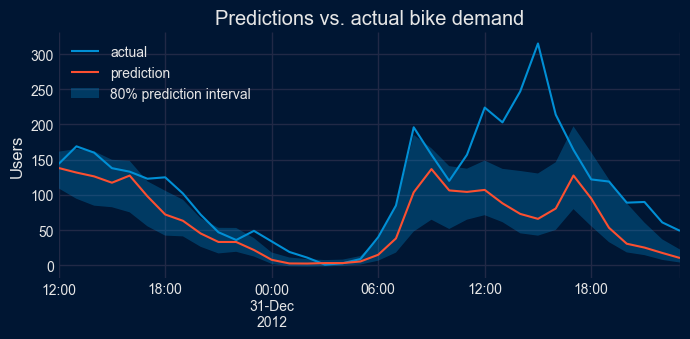

In [57]:
# Plot predictions vs. actual values for the held-out test period
# ==============================================================================
set_dark_theme()
preds = results_eval.predictions
fig, ax = plt.subplots(figsize=(7, 3.5))
data.set_index('date_time').loc[preds.index, 'users'].plot(ax=ax, label='actual')
preds['pred'].plot(ax=ax, label='prediction')
if {'lower_bound', 'upper_bound'}.issubset(preds.columns):
    ax.fill_between(
        preds.index, preds['lower_bound'], preds['upper_bound'],
        alpha=0.3, label='80% prediction interval'
    )
ax.set_title('Predictions vs. actual bike demand')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
# Ask the assistant to interpret the forecast results
# ==============================================================================
answer = assistant.ask(
    prompt  = "Explain the results of this forecast, including the metrics and predictions.",
    context = results_eval
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_52458/3255811032.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The recursive machine learning model successfully generated a 36-step hourly          │
│  forecast for the target variable, users, achieving a Mean Absolute Error (MAE) of     │
│  47.762864. The model outperformed the naive baseline as evidenced by a Mean Absolute  │
│  Scaled Error (MASE) of 0.741784, which is below the baseline threshold of 1. Point    │
│  predictions are provided alongside 80 percent prediction intervals computed via       │
│  bootstrapping.                                                                        │
│                                                                                        │
│  Model Evaluation Metrics                                                              │
│                                                                                        │
│  The model was evaluated using multiple key metrics:                                   │
│                                                                                        │
│   • Mean Absolute Error (MAE): 47.762864. This represents the average absolute         │
│     deviation of the predictions from the actual observed values.                      │
│   • Mean Squared Error (MSE): 4986.623147.                                             │
│   • Mean Absolute Scaled Error (MASE): 0.741784. Since this value is below 1, it       │
│     confirms that the forecasting model is more accurate than the naive baseline.      │
│   • Mean Absolute Percentage Error (MAPE): 0.482088.                                   │
│                                                                                        │
│  Forecast Predictions and Intervals                                                    │
│                                                                                        │
│  The forecast covers 36 hourly steps, starting on December 30, 2012, at 12:00:00. The  │
│  prediction intervals represent an 80 percent nominal coverage (spanning the 0.1 and   │
│  0.9 quantiles) calculated using bootstrapping.                                        │
│                                                                                        │
│  The summary of all 36 steps is as follows:                                            │
│                                                                                        │
│   • Predicted Values (pred): The predictions have a minimum of 2.570746494902905, a    │
│     maximum of 138.22469030179306, and a mean of 64.23551642583179.                    │
│   • Lower Prediction Bounds (lower_bound): The lower bounds have a minimum of          │
│     -1.7414334126085962, a maximum of 109.30392484101286, and a mean of                │
│     38.780076275550485.                                                                │
│   • Upper Prediction Bounds (upper_bound): The upper bounds have a minimum of          │
│     7.508038463459995, a maximum of 197.432013027649, and a mean of                    │
│     97.79468485354371.                                                                 │
│                                                                                        │
│  Because intermediate rows were omitted from the provided dataset, specific            │
│  progressions, daily trends, or direct comparisons between the early and late periods  │
│  of the forecast horizon cannot be analyzed.                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Prediction mode

In prediction mode, the model trains on the entire dataset and forecasts the next `steps` time points. Because the data includes exogenous variables (`holiday`, `weather`, `temp`), their future values must be supplied via the `exog` argument.

In [59]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(hours=1),
    periods=36,
    freq='h'
)

results_pred = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,        # Use the entire dataset (prediction mode)
    exog        = exog,        # Future values of exogenous variables
    profile     = profile,
    plan        = plan_refined
)

display(results_pred.predictions.head())

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_52458/3045858467.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(hours=1),


╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:292                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,16.836024,6.037629,27.152271
2013-01-01 01:00:00,10.863667,3.609791,17.129995
2013-01-01 02:00:00,7.228478,3.392406,15.947248
2013-01-01 03:00:00,4.947867,0.949713,13.476460
2013-01-01 04:00:00,4.788347,1.690810,13.218650


In [60]:
# Full results object
# ==============================================================================
results_pred

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                             

### Code-only mode

Use `forecast_code()` when you want to preview or export the reproducible script without executing it. This is useful for code review, auditing the generated pipeline, or running the script in a separate environment.

In [61]:
# Generate the reproducible script without executing it
# ==============================================================================
code_result = assistant.forecast_code(
    data        = data,
    steps       = 36,
    test_size   = 36,
    profile     = profile,
    plan        = plan_refined
)
code_result.show_code()

### The ForecastResult object

Both `forecast()` modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values. When intervals are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame or None | Evaluation metrics (`MAE`, `MSE`, `MASE`), one row per series. `None` in prediction mode. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

## Backtesting

The backtesting branch uses the same `profile` and `plan` as the forecast branch but evaluates the model's historical performance through time series cross-validation. The key decision is how to configure the `TimeSeriesFold` object, which controls exactly how the historical data is partitioned into successive training and test windows.

skforecast-ai provides three distinct ways to define this validation strategy:

1. **Explicit instantiation (recommended)**: manually construct a `TimeSeriesFold` and pass it directly to `backtest()`. Use this when you already know your exact operational constraints.

2. **Deterministic `create_cv()`**: allow the assistant to derive a sensible `TimeSeriesFold` from the profile and plan using rule-based defaults. You can override individual parameters explicitly.

3. **LLM `create_cv()` (with a prompt)**: describe your deployment use case in natural language. The LLM translates your description into a fully-configured `TimeSeriesFold`, accompanied by an explanation you can audit.

### Define the backtesting strategy

#### Manual TimeSeriesFold

In [62]:
# Create your own TimeSeriesFold object
# ==============================================================================
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
    steps              = 36,
    initial_train_size = end_train,
    refit              = False,
    verbose            = False
)
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = True,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### Deterministic create_cv()

In [63]:
# Let the assistant derive a TimeSeriesFold with rule-based defaults
# ==============================================================================
cv_det = assistant.create_cv(
    profile            = profile,
    plan               = plan_refined,
    initial_train_size = end_train,
    refit              = False,
)

cv_det

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step       │
│  horizon, 82 folds.                                                                    │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:59:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

#### LLM create_cv() with a natural-language

Rather than manually configuring `TimeSeriesFold` parameters, you can describe your backtesting strategy in natural language and let the assistant translate it into a rigorous cross-validation schema.

In [64]:
# Let the assistant create the TimeSeriesFold from a natural-language prompt
# ==============================================================================
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)
cv_llm = assistant.create_cv(
    profile = profile,
    plan    = plan_refined,
    prompt  = prompt
)

In [65]:
# Cross-validation strategy derived from the prompt
# ==============================================================================
cv_llm

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  The user requested that the model be trained exactly once on all data up to the end   │
│  of August 2012 (23:59), without refitting as the forecast window rolls forward. To    │
│  represent this, 'initial_train_size' is set to the specific cutoff timestamp          │
│  '2012-08-31 23:00:00' (reflecting the hourly frequency), and 'refit' is set to        │
│  False. This simulates a deploy-and-evaluate scenario where the model remains static.  │
│  Initial training up to 2012-08-31 23:00:00, expanding window, no refit, 36-step       │
│  horizon, 82 folds.                                                                    │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:00:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:00:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

In [66]:
# LLM reasoning behind the TimeSeriesFold configuration
# ==============================================================================
print(textwrap.fill(cv_llm.explanation, width=88))

The user requested that the model be trained exactly once on all data up to the end of
August 2012 (23:59), without refitting as the forecast window rolls forward. To
represent this, 'initial_train_size' is set to the specific cutoff timestamp '2012-08-31
23:00:00' (reflecting the hourly frequency), and 'refit' is set to False. This simulates
a deploy-and-evaluate scenario where the model remains static. Initial training up to
2012-08-31 23:00:00, expanding window, no refit, 36-step horizon, 82 folds.


Since the `prompt` correctly describes the intended use case, the `cv_llm` object returned by `create_cv()` matches the one we built manually. However, it was derived entirely from a natural-language description. The assistant also returns a `cv_llm_explanation` string that details the choices it made, allowing you to verify that the resulting `TimeSeriesFold` matches your intended strategy before executing the backtest.

### Run the backtest

In [67]:
# Run backtesting, reusing the pre-computed profile and plan
# ==============================================================================
results_backtest = assistant.backtest(
    data        = data,
    cv          = cv,           # TimeSeriesFold object
    interval    = [0.1, 0.9],   # 80% prediction interval
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:292                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/82 [00:00<?, ?it/s]

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 49.2198, mean_squared_error: 6400.4664,       │
│  mean_absolute_scaled_error: 0.8028, mean_absolute_percentage_error: 0.5391.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,49.219809,6400.466373,0.802796,0.539092


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,135.036736,108.542068,160.653403
2012-09-01 01:00:00,0,109.888204,76.178063,145.307721
2012-09-01 02:00:00,0,75.770462,47.850736,116.796935
2012-09-01 03:00:00,0,46.198413,24.296098,73.525209
2012-09-01 04:00:00,0,18.705054,6.001211,41.750443


In [68]:
# Plot prediction intervals vs real value
# ==============================================================================
predictions = results_backtest.predictions
data_test = data.set_index("date_time").loc[predictions.index, :]

fig = go.Figure([
    go.Scatter(name='Prediction', x=predictions.index, y=predictions['pred'], mode='lines'),
    go.Scatter(
        name='Real value', x=data_test.index, y=data_test['users'], mode='lines',
    ),
    go.Scatter(
        name='Upper Bound', x=predictions.index, y=predictions['upper_bound'], mode='lines',
        marker=dict(color="#444"), line=dict(width=0), showlegend=False
    ),
    go.Scatter(
        name='Lower Bound', x=predictions.index, y=predictions['lower_bound'], marker=dict(color="#444"),
        line=dict(width=0), mode='lines', fillcolor='rgba(68, 68, 68, 0.3)', fill='tonexty', showlegend=False
    )
])
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    hovermode="x",
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001),
    # Initial zoom on x axis betwee 1 oct to 10 oct
    xaxis=dict(range=['2012-10-01', '2012-10-10'])
)
fig.show()

In [69]:
# Ask the assistant to interpret the backtesting results
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the results of this backtesting, including the strategy, metrics, "
        "and predictions. Is the model good enough to deploy?"
    ),
    context = results_backtest
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_52458/2899763076.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The backtesting evaluated a recursive machine learning forecaster                     │
│  (ForecasterRecursive) using a LightGBM regressor, resulting in a Mean Absolute Error  │
│  of 49.2198. With a Mean Absolute Scaled Error of 0.8028, the model successfully       │
│  beats the naive baseline, indicating it is of sufficient quality to consider for      │
│  deployment.                                                                           │
│                                                                                        │
│  Backtesting Strategy                                                                  │
│                                                                                        │
│  The evaluation simulated real-world performance using the following configuration:    │
│                                                                                        │
│   • Type: A single-series ForecasterRecursive model with a LightGBM estimator.         │
│   • Folds: 82 folds with a 36-step forecast horizon and a fold stride of 36.           │
│   • Training: Initial training set ending at 2012-08-31 23:59:00, using a fixed        │
│     training window and no retraining during the backtesting folds (refit is False).   │
│   • Features: The model utilizes historical lags (1, 2, 3, 24, 48, 168), rolling       │
│     window features (window sizes of 4, 24, and 168), raw calendar features, and       │
│     exogenous variables (holiday, weather, and temp). Categorical handling is          │
│     configured automatically for the weather variable.                                 │
│                                                                                        │
│  Performance Metrics                                                                   │
│                                                                                        │
│  The historical simulation generated the following evaluation metrics:                 │
│                                                                                        │
│   • Mean Absolute Error (MAE): 49.219809                                               │
│   • Mean Squared Error (MSE): 6400.466373                                              │
│   • Mean Absolute Percentage Error (MAPE): 0.539092                                    │
│   • Mean Absolute Scaled Error (MASE): 0.802796                                        │
│                                                                                        │
│  A MASE below 1 indicates that the forecaster performs better than the naive baseline  │
│  model. At 0.802796, this model provides a meaningful accuracy gain over a simple      │
│  naive forecast.                                                                       │
│                                                                                        │
│  Prediction Characteristics                                                            │
│                                                                                        │
│  Across all 2928 predicted steps generated during backtesting:                         │
│                                                                                        │
│   • Point predictions have a minimum value of -0.7422423489148785, a maximum value of  │
│     858.4607406474361, and an overall mean of 228.1181017716306.                       │
│   • The 80% bootstrap prediction intervals provide uncertainty bounds, where the       │
│     lower bound has an overall mean of 182.56993197063656 and the upper bound has an   │
│     overall mean of 275.5779945038233.                                                 │
│                                                                                      

### Code-only mode

Use `backtest_code()` to generate the reproducible backtesting script without executing it.

In [70]:
# Generate the reproducible backtest script without executing it
# ==============================================================================
code_bt = assistant.backtest_code(
    data        = data,
    cv          = cv,
    profile     = profile,
    plan        = plan_refined
)
code_bt.show_code()

### The BacktestResult object

The `backtest()` method returns a `BacktestResult`, a lightweight container that bundles all the backtesting artifacts.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`), one row per series. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow. |
| `explanation` | str | Human-readable summary of the backtesting configuration and results. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

In [71]:
# Full results object
# ==============================================================================
results_backtest

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 49.2198, mean_squared_error: 6400.4664,       │
│  mean_absolute_scaled_error: 0.8028, mean_absolute_percentage_error: 0.5391.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │                True │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
                                     Backtest Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scale… ┃ mean_absolute_perce… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│             49.2198 │          6400.4664 │               0.8028 │               0.5391 │
└─────────────────────┴────────────────────┴──────────────────────┴──────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 135.0367 │    108.5421 │    160.6534 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │ 109.8882 │     76.1781 │    145.3077 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  75.7705 │     47.8507 │    116.7969 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  46.1984 │     24.2961 │     73.5252 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │  18.7051 │      6.0012 │     41.7504 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │  92.9370 │     48.0491 │    120.7935 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │  62.4571 │     29.6374 │     91.5321 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  38.0820 │     16.7702 │     71.5349 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  23.8581 │      9.3050 │ 

## Comparing forecaster configurations

Choosing a forecasting model should not rely on intuition alone. Two configurations that look equally reasonable can perform very differently once evaluated on real temporal data. The most reliable approach is to test every candidate under **identical conditions** and compare their metrics.

The `compare()` method does exactly that. It receives a list of candidate configurations, backtests each one using the same `TimeSeriesFold` strategy, and returns a leaderboard ranked by the selected metric.

In the step-by-step path, the key argument is `profile`. Passing the profile computed at the beginning of this tutorial skips profiling entirely and guarantees that every candidate is evaluated against the **same** data profile. Note that `compare()` does not accept a `plan`: each candidate derives its own plan from the shared profile, which is precisely what makes the candidates differ.

Candidates can be provided in two ways:

+ **Automatic candidates (`candidates=None`)**: the assistant builds the comparison set from `profile.forecaster_candidates`, using the forecaster types identified as suitable during profiling. This is useful when exploring a new dataset without a predefined shortlist.

+ **Explicit candidates (recommended)**: pass a list of `(name, config)` tuples, where `name` labels the row in the leaderboard and `config` holds the same override keys understood by `plan()`: `'forecaster'`, `'estimator'`, `'estimator_kwargs'`, `'lags'` and `'window_features'`. This provides full control and makes the resulting table easier to interpret.

A failed candidate does not stop the comparison. Instead, a `CandidateFailedWarning` is issued, the row records the error and is placed last.

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Tip</strong>
</p>

<p>

All candidates use the same cross-validation strategy, ensuring a fair comparison. However, the results are only meaningful if the <code>cv</code> setup reflects the real use case where the model will be deployed. For example, if the production system retrains weekly, the backtest should also refit weekly. If the model is expected to forecast 24 hours ahead, the backtest should use a 24-hour horizon.

The evaluation window must also be representative. A period that is too short or dominated by unusual events (holidays, outages, or exceptional peaks) may favor a candidate that performs poorly over time. Define the validation setup carefully before comparing models so the final ranking is reliable.

</p>

</div>

### Automatic candidates

In [72]:
# Compare the forecaster candidates suggested by the profile
# ==============================================================================
results_compare = assistant.compare(
    data        = data,
    cv          = cv,       # Same TimeSeriesFold used in the backtest above
    candidates  = None,     # Candidates suggested by the assistant 
    profile     = profile   # Reuse the pre-computed profile
)

Comparing forecasters:   0%|          | 0/3 [00:00<?, ?it/s]

In [73]:
# Ranked leaderboard
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,1,ForecasterFoundation,ForecasterFoundation,Chronos-2,38.436160,4231.326474,0.597467,0.611349
1,2,ForecasterRecursive,ForecasterRecursive,LGBMRegressor,46.312218,5495.881638,0.749598,0.472735
2,3,ForecasterDirect,ForecasterDirect,LGBMRegressor,49.298312,5936.622526,0.797930,0.499413


In [74]:
# Deterministic summary of the comparison
# ==============================================================================
results_compare.show_explanation()

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 3 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'ForecasterFoundation'                     │
│  (ForecasterFoundation / Chronos-2) = 38.4362, 17.0% ahead of 'ForecasterRecursive'    │
│  (46.3122).                                                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Explicit candidates

In practice, you will often already have a shortlist in mind: a fast baseline, a gradient boosting model, or a variant with a richer feature set. Passing explicit `(name, config)` tuples keeps the comparison focused and makes the resulting leaderboard easy to understand at a glance.

The `config` dictionary accepts the same overrides as `plan()`. Any omitted option falls back to the deterministic recommendation derived from the shared profile, so candidates can remain concise. For example, `{'forecaster': 'ForecasterDirect'}` changes only the forecaster while keeping the recommended estimator, lags, and features.

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Computational cost</strong>
</p>

<p>
Each candidate is backtested independently across all folds, so runtime increases with both the number and complexity of the configurations. Comparing four candidates will take roughly four times as long as running one backtest.

Start with a small set of clearly different options, review the results, and refine from there. Testing many near-identical variants is costly and rarely useful.
</p>

</div>

In [75]:
# Compare an explicit shortlist of configurations
# ==============================================================================
candidates = [
    (
        "ridge_baseline",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "Ridge",
            "lags"      : 24,
        }
    ),
    (
        "lgbm_daily_lags",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "refined_plan",
        {
            "forecaster"      : plan_refined.forecaster,
            "estimator"       : plan_refined.estimator,
            "lags"            : plan_refined.forecaster_kwargs.get("lags"),
            "window_features" : plan_refined.forecaster_kwargs.get("window_features"),
        }
    ),
    (
        "lgbm_direct",
        {
            "forecaster": "ForecasterDirect",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "foundation_model",
        {
            "forecaster": "ForecasterFoundation"
        }
    ),
]

results_compare = assistant.compare(
    data        = data,
    cv          = cv,
    candidates  = candidates,  # Specific candidates to compare
    metric      = ['mean_absolute_error', 'mean_absolute_scaled_error'],
    profile     = profile
)

Comparing forecasters:   0%|          | 0/5 [00:00<?, ?it/s]

The `refined_plan` candidate reuses the forecaster, estimator, lags and window features of the plan produced by `refine_plan()`. This is the recommended way to validate a refined plan: the leaderboard shows whether the extra domain knowledge actually improves the metrics compared to the deterministic baselines.

When several metrics are requested, all of them are shown as columns but only the **first** one drives the ranking.

In [76]:
# Ranked leaderboard, sorted by the first metric requested
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_absolute_scaled_error
0,1,foundation_model,ForecasterFoundation,Chronos-2,38.436160,0.597467
1,2,refined_plan,ForecasterRecursive,LGBMRegressor,49.219809,0.802796
2,3,lgbm_direct,ForecasterDirect,LGBMRegressor,50.224908,0.819189
3,4,lgbm_daily_lags,ForecasterRecursive,LGBMRegressor,55.517689,0.905517
4,5,ridge_baseline,ForecasterRecursive,Ridge,93.145620,1.519244


### Inspect individual candidates

Because every candidate is a full `BacktestResult`, the details of any individual configuration remain available, including its metrics, its predictions and the standalone script that generated them.

In [77]:
# Inspect a specific candidate
# ==============================================================================
candidate = results_compare.candidates['foundation_model']

display(candidate.metrics)
display(candidate.predictions.head())
candidate.show_code()

,mean_absolute_error,mean_absolute_scaled_error
0,38.43616,0.597467


,level,fold,pred
2012-09-01 00:00:00,users,0,148.059464
2012-09-01 01:00:00,users,0,102.715004
2012-09-01 02:00:00,users,0,66.084427
2012-09-01 03:00:00,users,0,40.878662
2012-09-01 04:00:00,users,0,29.577866


### Reuse the winning configuration

The most useful result of a comparison is often not the leaderboard, but `best_candidate`. It is a complete `BacktestResult` carrying both the winning `profile` and `plan`, so it can be fed back into the step-by-step workflow without manually rebuilding the configuration.

In [78]:
# Winning configuration
# ==============================================================================
print(f"Best candidate: {results_compare.best_name}")
results_compare.best_candidate.plan

Best candidate: foundation_model


              Forecast Plan              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type      │ foundation           │
├────────────────┼──────────────────────┤
│ Forecaster     │ ForecasterFoundation │
├────────────────┼──────────────────────┤
│ Estimator      │ Chronos-2            │
├────────────────┼──────────────────────┤
│ Steps          │ 36                   │
├────────────────┼──────────────────────┤
│ Frequency      │ h                    │
├────────────────┼──────────────────────┤
│ Use exog       │ True                 │
├────────────────┼──────────────────────┤
│ Interval       │ None                 │
├────────────────┼──────────────────────┤
│ Primary metric │ mean_absolute_error  │
├────────────────┼──────────────────────┤
│ Preprocessing  │ 1 step               │
└────────────────┴──────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather'].       │
│                         │ Chronos-2 consumes categorical covariates natively, so no    │
│                         │ encoding is needed.                                          │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterFoundation + Chronos-2. No lag or window features: the foundation     │
│  model forecasts directly from the raw context window. Exogenous variables included.   │
│  MAE is interpretable, robust to outliers, and works at any scale.                     │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

In [79]:
# Produce the final forecast with the winning configuration
# ==============================================================================
results_pred_best = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,                                # Prediction mode
    exog        = exog,                                # Future values of exogenous variables
    profile     = results_compare.profile,             # Shared profile
    plan        = results_compare.best_candidate.plan  # Winning plan
)

results_pred_best.show_code()

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ A pre-built `plan` was provided, so the following argument(s) are ignored:           │
│ ['interval']. To change these, refine the plan with `refine_plan()` before calling.  │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-pa │
│ ckages/skforecast_ai/_utils.py:292                                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

### Explain mode (comparison)

Like any other result, a `ComparisonResult` can be passed to `ask()` as `context` to explain why the ranking looks the way it does. However, the LLM cannot change the outcome: all metrics and rankings are computed deterministically before it sees the result.

In [80]:
# Ask the assistant to interpret the comparison
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the comparison results. Is the margin between the top candidates "
        "meaningful, or are they practically equivalent?"
    ),
    context = results_compare
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_52458/2209842622.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The evaluation of five forecasting candidates shows that the foundation_model (using  │
│  ForecasterFoundation with Chronos-2) outperformed all other configurations,           │
│  achieving the lowest mean absolute error of 38.436160. According to the pre-computed  │
│  summary, the winning model is 21.9% ahead of the second-place candidate,              │
│  refined_plan, which represents a clear and meaningful performance margin.             │
│  Additionally, four out of the five candidates successfully beat the naive baseline.   │
│                                                                                        │
│  Performance Leaderboard                                                               │
│                                                                                        │
│  The candidates are ranked in ascending order by their mean absolute error:            │
│                                                                                        │
│   • Rank 1: foundation_model (ForecasterFoundation with Chronos-2) achieved a Mean     │
│     Absolute Error (MAE) of 38.436160 and a Mean Absolute Scaled Error (MASE) of       │
│     0.597467.                                                                          │
│   • Rank 2: refined_plan (ForecasterRecursive with LGBMRegressor) achieved an MAE of   │
│     49.219809 and a MASE of 0.802796.                                                  │
│   • Rank 3: lgbm_direct (ForecasterDirect with LGBMRegressor) achieved an MAE of       │
│     50.224908 and a MASE of 0.819189.                                                  │
│   • Rank 4: lgbm_daily_lags (ForecasterRecursive with LGBMRegressor) achieved an MAE   │
│     of 55.517689 and a MASE of 0.905517.                                               │
│   • Rank 5: ridge_baseline (ForecasterRecursive with Ridge) achieved an MAE of         │
│     93.145620 and a MASE of 1.519244.                                                  │
│                                                                                        │
│  Margin and Metric Interpretation                                                      │
│                                                                                        │
│  The Mean Absolute Scaled Error (MASE) allows us to evaluate model performance         │
│  against a naive baseline. A MASE value below 1 indicates that the model beats the     │
│  naive baseline, while a value above 1 does not.                                       │
│                                                                                        │
│   • The top four candidates (foundation_model, refined_plan, lgbm_direct, and          │
│     lgbm_daily_lags) all achieved MASE values below 1 (ranging from 0.597467 to        │
│     0.905517), confirming they successfully beat the naive baseline.                   │
│   • The ridge_baseline failed to beat the baseline, finishing last with a MASE of      │
│     1.519244.                                                                          │
│   • The margin between the top two candidates is distinct and meaningful. Rather than  │
│     achieving equivalent results, the foundation_model (MAE 38.436160) holds a 21.9%   │
│     performance advantage over the refined_plan (MAE 49.219809). This indicates a      │
│     notable improvement in forecasting accuracy when utilizing the pre-trained         │
│     foundation model on this hourly dataset.                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### The ComparisonResult object

The `compare()` method returns a `ComparisonResult`, which groups the shared setup, the ranked leaderboard, and the individual backtests in a single object.

| Attribute | Type | Description |
|---|---|---|
| `results` | DataFrame | Ranked leaderboard, one row per candidate, sorted best to worst. Columns: `rank`, `name`, `forecaster`, `estimator`, the metric columns, and `error` when at least one candidate failed. |
| `candidates` | dict | Mapping of candidate name to the full `BacktestResult` object. |
| `failures` | dict | Mapping of candidate name to a `CandidateFailure` describing why it failed. Empty when every candidate succeeds. |
| `ranking_metric` | str | Name of the metric used to sort `results`. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters plus the resulting `n_folds`, applied identically to every candidate. |
| `profile` | `ForecastingProfile` | The shared data profile behind every candidate. |
| `explanation` | str | Deterministic, human-readable summary of the comparison. |
| `best_name` | str | Name of the top-ranked candidate. |
| `best_candidate` | `BacktestResult` | Top-ranked candidate as a complete `BacktestResult`. |

In [81]:
# Full results object
# ==============================================================================
results_compare

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 5 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'foundation_model' (ForecasterFoundation   │
│  / Chronos-2) = 38.4362, 21.9% ahead of 'refined_plan' (49.2198).                      │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                    Comparison Results                                    
┏━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Index ┃ rank ┃         name ┃   forecaster ┃    estimator ┃ mean_absol… ┃ mean_absolu… ┃
┡━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0     │    1 │ foundation_… │ ForecasterF… │    Chronos-2 │     38.4362 │       0.5975 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 1     │    2 │ refined_plan │ ForecasterR… │ LGBMRegress… │     49.2198 │       0.8028 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 2     │    3 │  lgbm_direct │ ForecasterD… │ LGBMRegress… │     50.2249 │       0.8192 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 3     │    4 │ lgbm_daily_… │ ForecasterR… │ LGBMRegress… │     55.5177 │       0.9055 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 4     │    5 │ ridge_basel… │ ForecasterR… │        Ridge │     93.1456 │       1.5192 │
└───────┴──────┴──────────────┴──────────────┴──────────────┴─────────────┴──────────────┘

## Reproducible code

Every forecast or backtest workflow exposes the standalone skforecast script used to produce its results. This script is strictly deterministic, ensuring identical outputs for a given set of inputs and configurations. You can access the code at any time via the `show_code()` method.

## Free-form Q&A

The `ask()` method is not limited to interpreting workflow objects. Without any `context` attached, it works as a general forecasting knowledge assistant, useful for clarifying methodology, choosing between approaches, or understanding metric trade-offs.

In [82]:
# Ask a general forecasting question (no data or result required)
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "For hourly demand with strong daily and weekly seasonality, when should "
        "I prefer a direct forecasting strategy over a recursive one?"
    )
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  For hourly demand with strong daily and weekly seasonality, you should prefer a       │
│  direct forecasting strategy when you need to predict a long horizon (such as 24       │
│  hours or a full 168-hour week) and want to avoid the accumulation of estimation       │
│  errors that occurs with recursive models. It is also highly effective when the        │
│  relationship between past observations and the target changes depending on the        │
│  specific hour being predicted. Because a direct forecaster trains a separate model    │
│  for each individual step, it can better capture hour-specific dynamics without        │
│  letting early prediction errors cascade through the horizon.                          │
│                                                                                        │
│  Key Scenarios to Prefer a Direct Strategy                                             │
│                                                                                        │
│   • Avoiding error propagation: In recursive forecasting, the prediction for hour 1    │
│     is used as an input to predict hour 2, which is then used to predict hour 3, and   │
│     so on. Over long horizons like a day or week, small errors can accumulate          │
│     rapidly. A direct strategy trains independent models for each step, completely     │
│     avoiding this feedback loop of errors.                                             │
│   • Capturing step-specific relationships: The factors influencing demand 1 hour from  │
│     now are often different from those influencing demand 24 or 48 hours from now. A   │
│     direct forecaster allows the estimator to learn unique weights or patterns for     │
│     each specific step in the horizon.                                                 │
│   • Utilizing step-specific exogenous variables: If you have hourly forecasts for      │
│     exogenous variables (such as temperature or holidays), direct models can map       │
│     those inputs directly to each specific forecast step.                              │
│                                                                                        │
│  Trade-offs to Keep in Mind                                                            │
│                                                                                        │
│   • Computation time: Training a direct forecaster to predict a weekly horizon (168    │
│     hours) requires training 168 independent machine learning models. This is much     │
│     slower and uses more memory than training a single recursive model, though it can  │
│     be parallelized using the n_jobs parameter.                                        │
│   • Fixed forecast horizon: Unlike recursive models, which can forecast any number of  │
│     steps at prediction time, direct models require you to specify the maximum number  │
│     of steps (steps) during initialization. You cannot forecast beyond this            │
│     pre-defined limit without retraining.                                              │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Summary

This tutorial covered the **step-by-step path** of `skforecast-ai`. Here is a recap of what each stage does and when to use it:

| Step | Method | When to use |
|---|---|---|
| 1. Profile | `profile()` | Always: produces the `ForecastingProfile` required by all downstream methods. |
| 2. Plan | `plan()` | Always: converts the profile into an executable configuration. |
| 3. Refine plan | `refine_plan()` | Optional: use when you want to override specific decisions (deterministic) or inject domain knowledge (LLM). Always evaluate the result. |
| 4a. Forecast | `forecast()` | When you want future predictions or a held-out evaluation in a single execution. |
| 4a. Code only | `forecast_code()` | When you want to preview or export the script without running it. |
| 4b. CV strategy | `create_cv()` | When you want the assistant to derive or translate a `TimeSeriesFold` for you. |
| 4b. Backtest | `backtest()` | When you want to evaluate the model over multiple historical folds. |
| 4b. Code only | `backtest_code()` | When you want to preview or export the backtesting script without running it. |
| 4c. Compare | `compare()` | When you want to rank several configurations under an identical cross-validation strategy and reuse the winner. |
| Any time | `ask()` | When you want an LLM explanation of any intermediate object or result, or a general forecasting Q&A. |

The key advantage of this path is that the `profile` and `plan` are built **once** and reused across both the forecast and backtest branches. This avoids redundant profiling and ensures that both branches use the same modeling configuration. The same profile can also be handed to `compare()`, so every candidate is ranked against the very same data profile.

For a faster alternative that runs the entire pipeline in a single call, see the [fast-path tutorial](./agentic-forecasting.html). For a comprehensive overview of backtesting mechanics, see the [skforecast backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).